### Firsts level model for visuomotor tasks

In [1]:
import os
import os.path as op
import pandas as pd
import numpy as np
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting
from IPython.display import display

In [10]:
from pathlib import Path

# Parent directory that holds all HCA subject folders
hcp_root = Path("shared/data/HCP-Aging")

hca_folders = sorted(
    p for p in hcp_root.iterdir()
    if p.is_dir() and p.name.startswith("HCA") and any(p.iterdir())
)

hca_names = [p.name for p in hca_folders]

print(f"Found {len(hca_names)} non-empty HCA* folders in {hcp_root}")
hca_names

Found 53 non-empty HCA* folders in shared/data/HCP-Aging


['HCA6002236_V3_MR',
 'HCA6005242_V2_MR',
 'HCA6007044_V3_MR',
 'HCA6007044_V4_MR',
 'HCA6016146_V2_MR',
 'HCA6016146_V3_MR',
 'HCA6018857_V3_MR',
 'HCA6031344_V3_MR',
 'HCA6031344_V4_MR',
 'HCA6037457_V3_MR',
 'HCA6054457_V3_MR',
 'HCA6062456_V3_MR',
 'HCA6072156_V3_MR',
 'HCA6072156_V4_MR',
 'HCA6130548_V2_MR',
 'HCA6131449_V2_MR',
 'HCA6166973_V3_MR',
 'HCA6174770_V2_MR',
 'HCA6183064_V2_MR',
 'HCA6228767_V3_MR',
 'HCA6276475_V3_MR',
 'HCA6281872_V3_MR',
 'HCA6283371_V2_MR',
 'HCA6283371_V3_MR',
 'HCA6290368_V3_MR',
 'HCA6290368_V4_MR',
 'HCA6291976_V2_MR',
 'HCA6302349_V3_MR',
 'HCA6330152_V3_MR',
 'HCA6374576_V3_MR',
 'HCA6397992_V2_MR',
 'HCA6397992_V3_MR',
 'HCA6427066_V3_MR',
 'HCA6429272_V3_MR',
 'HCA6429272_V4_MR',
 'HCA6464678_V3_MR',
 'HCA6474782_V3_MR',
 'HCA6542470_V3_MR',
 'HCA7348277_V3_MR',
 'HCA7350567_V2_MR',
 'HCA7434674_V2_MR',
 'HCA7452272_V2_MR',
 'HCA7452575_V3_MR',
 'HCA7453981_V2_MR',
 'HCA7453981_V3_MR',
 'HCA7467588_V3_MR',
 'HCA7469592_V3_MR',
 'HCA7497395_

In [11]:
home_dir = "/home/jovyan"

# Paste the list of participants here (HCP-Aging subject IDs, e.g. "HCA6002236_V3_MR")
# participants = ["HCA6007044_V3_MR"]
participants = hca_names

out_path = op.join(home_dir, "VISMOTOR_GLM")
os.makedirs(out_path, exist_ok=True)

tr = 0.8  # repetition time (s) - replace with actual TR

contrasts = {
    "left": "left",
    "right": "right",
    "error": "error",
    "left_gt_right": "left - right",
    "right_gt_left": "right - left",
}

In [12]:
successful_subjects = []

for participant in participants:
    sub_out_dir = op.join(out_path, participant)

    # --- Locate psychopy events file ---
    data_dir = op.join(home_dir, "shared", "data", "HCP-Aging", participant,
                        "unprocessed", "tfMRI_VISMOTOR_PA", "LINKED_DATA", "PSYCHOPY")
    fname = f"VISMOTOR_{participant}_A_run1_wide.csv"
    fname_corr = fname.replace("_MR", "").rstrip("_")
    psychopy_file = op.join(data_dir, fname_corr)

    if not op.exists(psychopy_file):
        print(f"[skip] {participant}: events file not found ({psychopy_file})")
        continue

    os.makedirs(sub_out_dir, exist_ok=True)

    # --- Build events file ---
    df = pd.read_csv(psychopy_file)

    # Keep only actual task trials
    trials = df[df["targetStartTime"].notna() & df["targetEndTime"].notna()].copy()

    events = pd.DataFrame({
        "onset": trials["targetStartTime"].astype(float),
        "duration": (trials["targetEndTime"] - trials["targetStartTime"]).astype(float),
        "trial_type": trials["side"].astype(str),
    })
    events["accuracy"] = trials["correct"].astype(str)
    events["rt"] = pd.to_numeric(trials["firstRt"], errors="coerce")

    # Fold incorrect/missed trials into a combined "error" regressor
    events["trial_type"] = np.where(
        events["accuracy"].astype(str).str.lower().isin(["false", "0", "nan"]),
        "error",
        events["trial_type"],
    )

    events_file = op.join(sub_out_dir, f"{participant}_task-vismotor_run-01_events.tsv")
    events.to_csv(events_file, sep="\t", index=False)

    events_glm = events[["onset", "duration", "trial_type"]].copy()

    # --- Locate preprocessed BOLD + brain mask ---
    results_dir = op.join(home_dir, "shared", "data", "HCP-Aging", participant,
                           "MNINonLinear", "Results", "tfMRI_VISMOTOR_PA")
    fmri_img = op.join(results_dir, "tfMRI_VISMOTOR_PA_hp0_clean_rclean_tclean.nii.gz")
    mask_img = op.join(results_dir, "tfMRI_VISMOTOR_PA_finalmask.nii.gz")

    if not op.exists(fmri_img):
        print(f"[skip] {participant}: BOLD file not found in {results_dir}")
        continue
    if not op.exists(mask_img):
        print(f"[skip] {participant}: mask file not found in {results_dir}")
        continue

    # --- Fit first-level model ---
    try:
        glm = FirstLevelModel(
            t_r=tr,
            hrf_model="spm",
            drift_model="cosine",
            high_pass=0.01,
            noise_model="ar1",
            signal_scaling=False,
            standardize=False,
            minimize_memory=False,   # keeps residuals/predictions if you want them
            mask_img=mask_img,
        )
        glm = glm.fit(fmri_img, events=events_glm)

        # Save statistical maps
        for name, expr in contrasts.items():
            z_map = glm.compute_contrast(expr, output_type="z_score")
            t_map = glm.compute_contrast(expr, output_type="stat")
            eff_map = glm.compute_contrast(expr, output_type="effect_size")
            var_map = glm.compute_contrast(expr, output_type="effect_variance")

            z_map.to_filename(op.join(sub_out_dir, f"{participant}_{name}_zmap.nii.gz"))
            t_map.to_filename(op.join(sub_out_dir, f"{participant}_{name}_tmap.nii.gz"))
            eff_map.to_filename(op.join(sub_out_dir, f"{participant}_{name}_betamap.nii.gz"))
            var_map.to_filename(op.join(sub_out_dir, f"{participant}_{name}_varmap.nii.gz"))

        # Save design matrix
        design = glm.design_matrices_[0]
        design.to_csv(op.join(sub_out_dir, f"{participant}_design_matrix.tsv"), sep="\t", index=False)

        successful_subjects.append(participant)
        print(f"[done] {participant}: GLM completed")

    except Exception as e:
        print(f"[fail] {participant}: GLM failed ({e})")

print("\nGLM completed successfully for:")
for s in successful_subjects:
    print(f"  {s}")

[done] HCA6002236_V3_MR: GLM completed
[skip] HCA6005242_V2_MR: events file not found (/home/jovyan/shared/data/HCP-Aging/HCA6005242_V2_MR/unprocessed/tfMRI_VISMOTOR_PA/LINKED_DATA/PSYCHOPY/VISMOTOR_HCA6005242_V2_A_run1_wide.csv)


/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  retu

[done] HCA6007044_V3_MR: GLM completed


/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  retu

[done] HCA6007044_V4_MR: GLM completed
[skip] HCA6016146_V2_MR: events file not found (/home/jovyan/shared/data/HCP-Aging/HCA6016146_V2_MR/unprocessed/tfMRI_VISMOTOR_PA/LINKED_DATA/PSYCHOPY/VISMOTOR_HCA6016146_V2_A_run1_wide.csv)


...

[done] HCA7469592_V3_MR: GLM completed
[done] HCA7497395_V2_MR: GLM completed
[done] HCA7497901_V3_MR: GLM completed
[done] HCA7519581_V1_MR: GLM completed


/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)


[fail] HCA7530670_V3_MR: GLM failed (The expression (error) is not valid. This could be due to defining the contrasts using design matrix columns that are invalid python identifiers.)


/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/srv/conda/envs/notebook/lib/python3.10/site-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  retu

[done] HCA7530670_V4_MR: GLM completed
[done] HCA7536884_V2_MR: GLM completed

GLM completed successfully for:
  HCA6002236_V3_MR
  HCA6007044_V3_MR
  HCA6007044_V4_MR
  HCA6016146_V3_MR
  HCA6031344_V3_MR
  HCA6031344_V4_MR
  HCA6037457_V3_MR
  HCA6054457_V3_MR
  HCA6072156_V4_MR
  HCA6131449_V2_MR
  HCA6166973_V3_MR
  HCA6183064_V2_MR
  HCA6228767_V3_MR
  HCA6276475_V3_MR
  HCA6281872_V3_MR
  HCA6283371_V2_MR
  HCA6283371_V3_MR
  HCA6290368_V3_MR
  HCA6291976_V2_MR
  HCA6302349_V3_MR
  HCA6330152_V3_MR
  HCA6374576_V3_MR
  HCA6397992_V2_MR
  HCA6397992_V3_MR
  HCA6427066_V3_MR
  HCA6429272_V3_MR
  HCA6429272_V4_MR
  HCA6464678_V3_MR
  HCA6474782_V3_MR
  HCA7348277_V3_MR
  HCA7350567_V2_MR
  HCA7434674_V2_MR
  HCA7452575_V3_MR
  HCA7453981_V2_MR
  HCA7469592_V3_MR
  HCA7497395_V2_MR
  HCA7497901_V3_MR
  HCA7519581_V1_MR
  HCA7530670_V4_MR
  HCA7536884_V2_MR


#### Visualize statistical maps for a sample subject

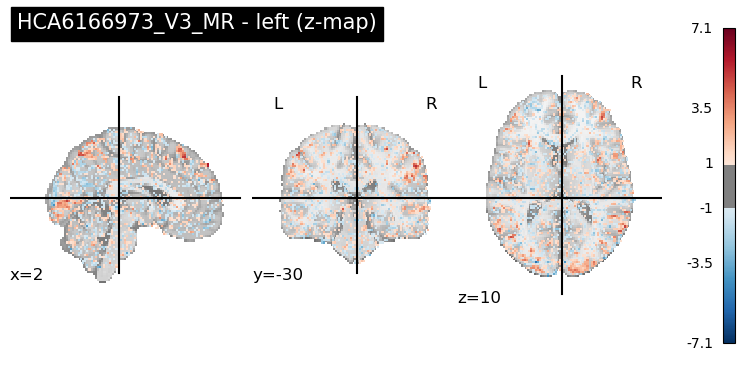

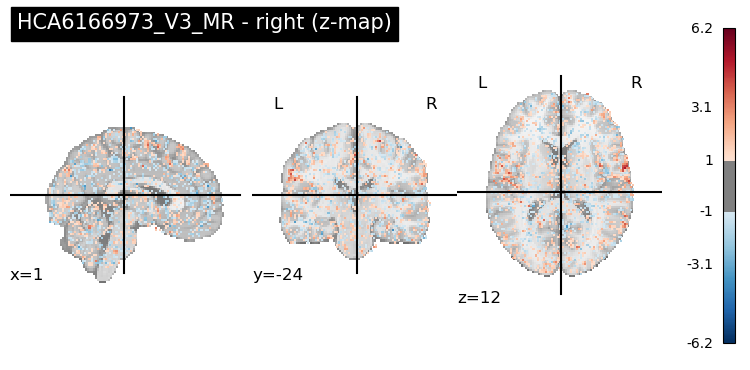

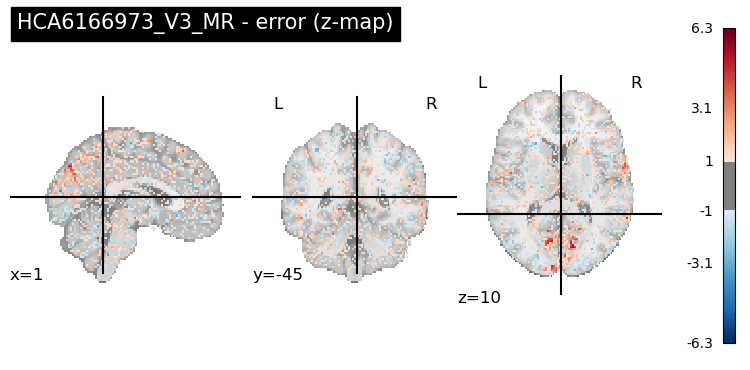

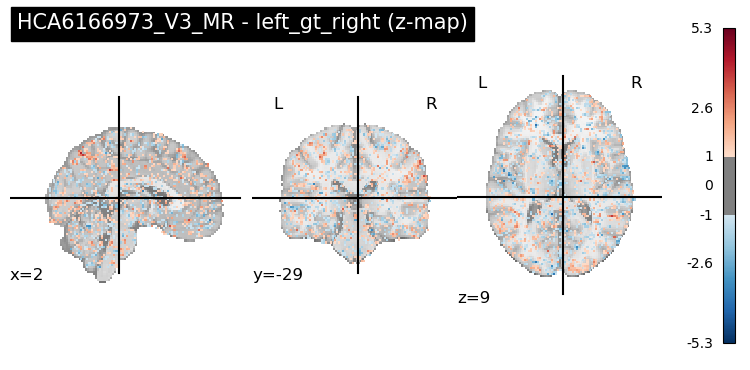

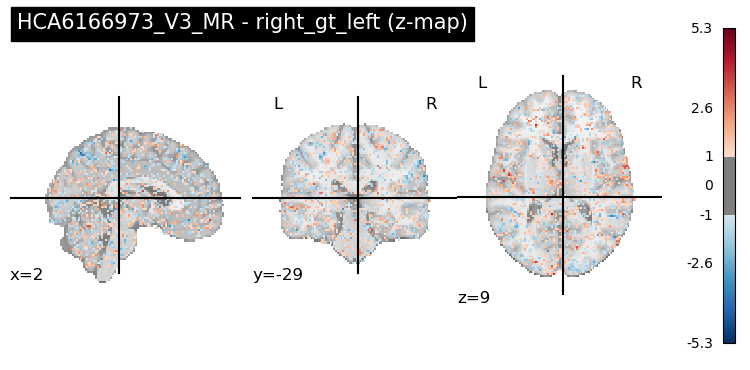

In [13]:
# Pick a sample subject to visualize (first successful subject, if available)
sample_subject = successful_subjects[10] if successful_subjects else participants[0]
sample_out_dir = op.join(out_path, sample_subject)

for name in contrasts:
    zmap_file = op.join(sample_out_dir, f"{sample_subject}_{name}_zmap.nii.gz")
    if not op.exists(zmap_file):
        print(f"[skip] {name}: z-map not found ({zmap_file})")
        continue

    plotting.plot_stat_map(
        zmap_file,
        threshold=1.0,
        display_mode="ortho",
        title=f"{sample_subject} - {name} (z-map)",
    )

plotting.show()

/srv/conda/envs/notebook/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



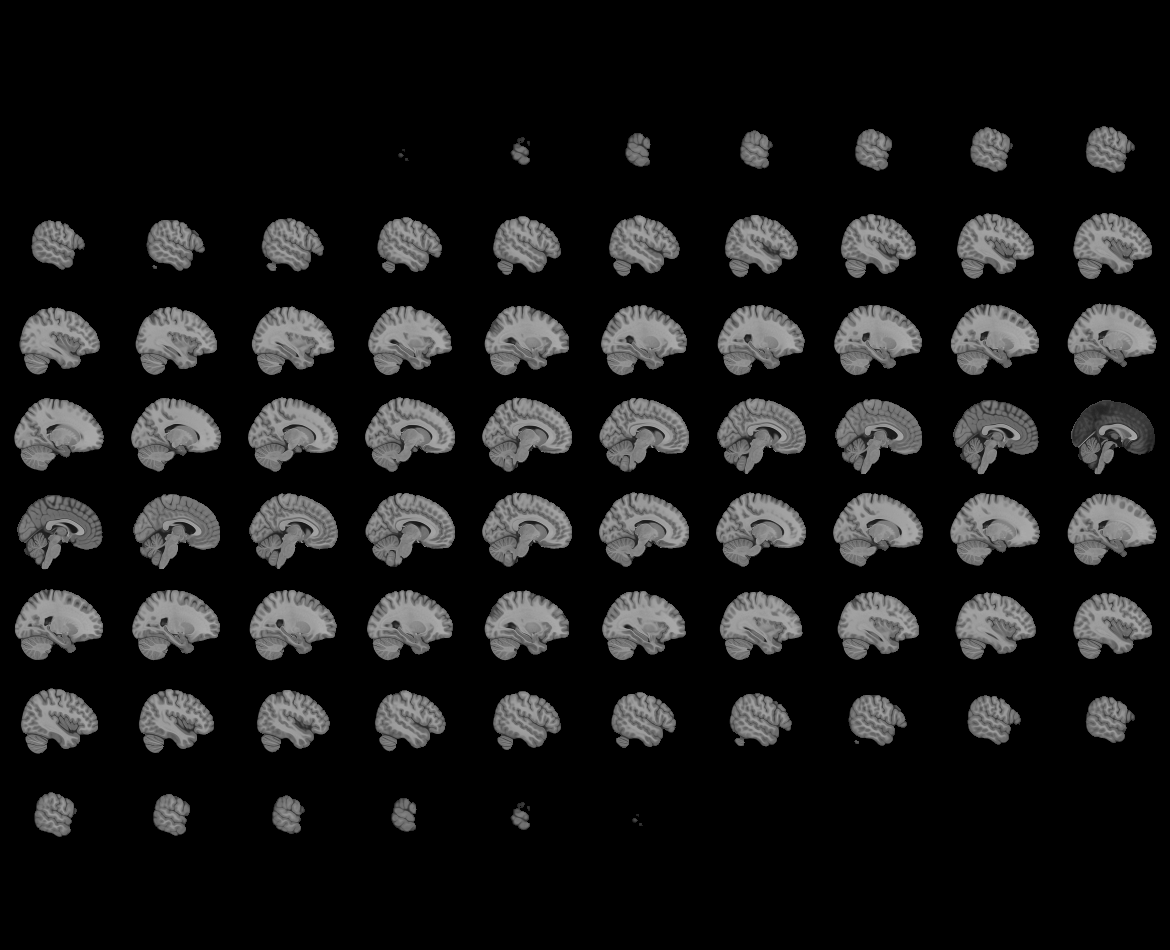
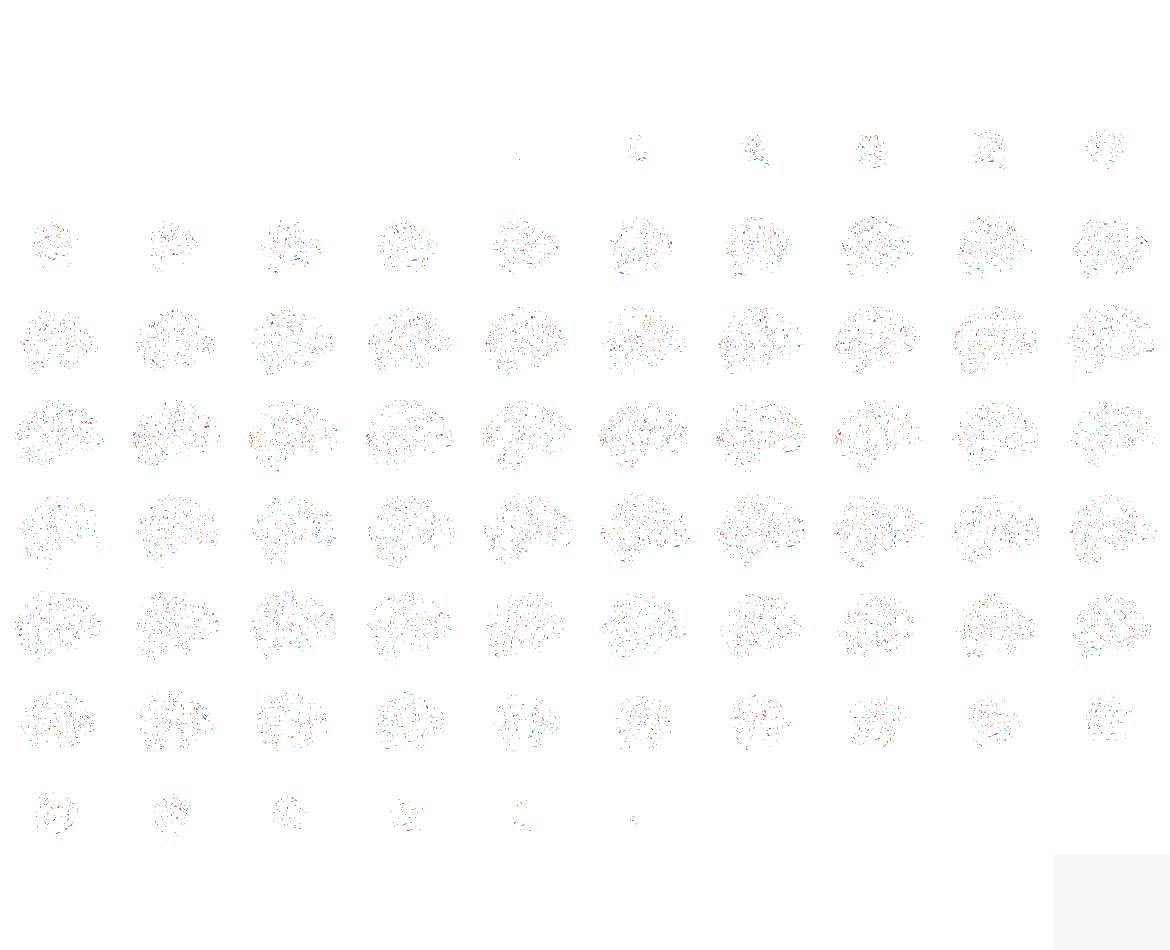

In [9]:
# Interactive viewer for a single contrast's z-map
contrast_to_view = "left_gt_right"
zmap_file = op.join(sample_out_dir, f"{sample_subject}_{contrast_to_view}_zmap.nii.gz")

html_view = plotting.view_img(
    zmap_file,
    threshold=2.0,
    title=f"{sample_subject} - {contrast_to_view} (z-map)",
)
display(html_view)